<a href="https://colab.research.google.com/github/AlexAndrianov/ICT728_sentiment_and_trend_analysis/blob/Syeda-sanzida-khatun-patch-1/ICT729_Week8_Clustering_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA

csv file loading

In [8]:
df = pd.read_csv("sample_data/Twitter- datasets.csv")
df.head()

,id,user_posted,name,description,date_posted,photos,url,tagged_users,replies,reposts,...,posts_count,profile_image_link,following,is_verified,quotes,bookmarks,parent_post_details,external_image_urls,videos,quoted_post
0,1868428607451799983,Glo███ews███,Glo███ews███,"Com o fim da ditadura Assad, muitos sírios con...","""2024-12-15T22:51:08.000Z""",NaN,https://x.com/GloboNews/status/186842860745179...,NaN,2,1,...,222223,https://pbs.twimg.com/profile_images/155910271...,122,False,1,1,"{""post_id"":null,""profile_id"":null,""profile_nam...",NaN,"[{""duration"":148167,""video_url"":""https://video...","{""data_posted"":null,""description"":null,""photos..."
1,1868159094567121215,bil███ard███,bil███ard███,Brian Austin Green Tells MGK to ‘Grow Up’ Afte...,"""2024-12-15T05:00:11.000Z""",NaN,https://x.com/billboard/status/186815909456712...,NaN,7,3,...,357584,https://pbs.twimg.com/profile_images/169657720...,3784,False,1,2,"{""post_id"":null,""profile_id"":null,""profile_nam...","[""https://pbs.twimg.com/card_img/1867636129563...",NaN,"{""data_posted"":null,""description"":null,""photos..."
2,1868451534708883739,TNT███rts███,TNT███ort███R,VENCE O PSG NO CLÁSSICO! 💪🇫🇷 Nossa @claalbuque...,"""2024-12-16T00:22:14.000Z""",NaN,https://x.com/TNTSportsBR/status/1868451534708...,"[{""biography"":null,""followers"":null,""following...",2,1,...,456734,https://pbs.twimg.com/profile_images/180701304...,859,False,0,1,"{""post_id"":null,""profile_id"":null,""profile_nam...",NaN,"[{""duration"":94861,""video_url"":""https://video....","{""data_posted"":null,""description"":null,""photos..."
3,1868441382022717466,TNT███rts███,TNT███ort███R,ÍDOLO E AGORA PRESIDENTE! 🇦🇷🇦🇷 O ex-atacante D...,"""2024-12-15T23:41:54.000Z""","[""https://pbs.twimg.com/media/Ge4JhOgXcAAQy5K....",https://x.com/TNTSportsBR/status/1868441382022...,"[{""biography"":null,""followers"":null,""following...",6,5,...,456734,https://pbs.twimg.com/profile_images/180701304...,859,False,1,3,"{""post_id"":null,""profile_id"":null,""profile_nam...",NaN,NaN,"{""data_posted"":null,""description"":null,""photos..."
4,1868418260892565925,Glo███ews███,Glo███ews███,.@DanielaLima_ : cirurgia de Lula travou negoc...,"""2024-12-15T22:10:01.000Z""",NaN,https://x.com/GloboNews/status/186841826089256...,"[{""biography"":null,""followers"":null,""following...",50,4,...,222223,https://pbs.twimg.com/profile_images/155910271...,122,False,3,3,"{""post_id"":null,""profile_id"":null,""profile_nam...",NaN,"[{""duration"":127067,""video_url"":""https://video...","{""data_posted"":null,""description"":null,""photos..."


In [9]:
text_column = "description"

Clean data

In [10]:
df = df.dropna(subset=[text_column])
df[text_column].head()

,description
0,"Com o fim da ditadura Assad, muitos sírios con..."
1,Brian Austin Green Tells MGK to ‘Grow Up’ Afte...
2,VENCE O PSG NO CLÁSSICO! 💪🇫🇷 Nossa @claalbuque...
3,ÍDOLO E AGORA PRESIDENTE! 🇦🇷🇦🇷 O ex-atacante D...
4,.@DanielaLima_ : cirurgia de Lula travou negoc...


In [11]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df[text_column].apply(clean_text)

TF-IDF and SVF improvement

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=1500,
    ngram_range=(1, 2)
)

X = vectorizer.fit_transform(df["clean_text"])

svd = TruncatedSVD(n_components=100, random_state=42)
X_reduced = svd.fit_transform(X)

testing k values and metrics

In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import pandas as pd

results = []

for k in range(5, 13):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_reduced)

    results.append({
        "k": k,
        "Silhouette": silhouette_score(X_reduced, labels),
        "Calinski-Harabasz": calinski_harabasz_score(X_reduced, labels),
        "Davies-Bouldin": davies_bouldin_score(X_reduced, labels)
    })

metrics_df = pd.DataFrame(results)
metrics_df

,k,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,5,0.164786,39.306014,1.561772
1,6,0.079493,32.737800,1.851933
2,7,0.086279,33.969782,2.016485
3,8,0.106087,33.188795,1.472442
4,9,0.103267,33.283667,2.418626
5,10,0.112969,32.273590,2.030587
6,11,0.120672,33.733000,1.873726
7,12,0.142062,32.055664,1.457818


selecting best K

In [14]:
best_k = metrics_df.sort_values("Silhouette", ascending=False).iloc[0]["k"]
best_k

np.float64(5.0)

In [15]:
best_k = int(best_k)
best_k

5

In [16]:
from sklearn.cluster import KMeans

final_model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["cluster"] = final_model.fit_predict(X_reduced)

df[["description", "cluster"]].head()

,description,cluster
0,"Com o fim da ditadura Assad, muitos sírios con...",0
1,Brian Austin Green Tells MGK to ‘Grow Up’ Afte...,0
2,VENCE O PSG NO CLÁSSICO! 💪🇫🇷 Nossa @claalbuque...,0
3,ÍDOLO E AGORA PRESIDENTE! 🇦🇷🇦🇷 O ex-atacante D...,0
4,.@DanielaLima_ : cirurgia de Lula travou negoc...,0


hashtag validation

In [19]:
from collections import Counter
import re

def extract_hashtags(text):
    return re.findall(r"#\w+", str(text).lower())

df["hashtags"] = df["description"].apply(extract_hashtags)

print("\n--- Cluster Hashtag Summary ---")

for cluster in sorted(df["cluster"].unique()):
    tags = []

    for t in df[df["cluster"] == cluster]["hashtags"]:
        tags.extend(t)

    print(f"\nCluster {cluster}:")
    print(Counter(tags).most_common(5))


--- Cluster Hashtag Summary ---

Cluster 0:
[('#melhoresdoano', 60), ('#domingão', 60), ('#premiersportscup', 33), ('#barclayswsl', 31), ('#mancity', 24)]

Cluster 1:
[('#טהרן', 3), ('#אויבים', 1), ('#ערב_עם_שי_שטרן', 1), ('#מועדון_סטנדאפ', 1), ('#פגישה', 1)]

Cluster 2:
[('#mufc', 30), ('#mcimun', 29), ('#muwomen', 1)]

Cluster 3:
[('#ufctampa', 44), ('#easytocelebrate', 1)]

Cluster 4:
[('#cpfc', 26), ('#bhacry', 24)]


metrics vs k

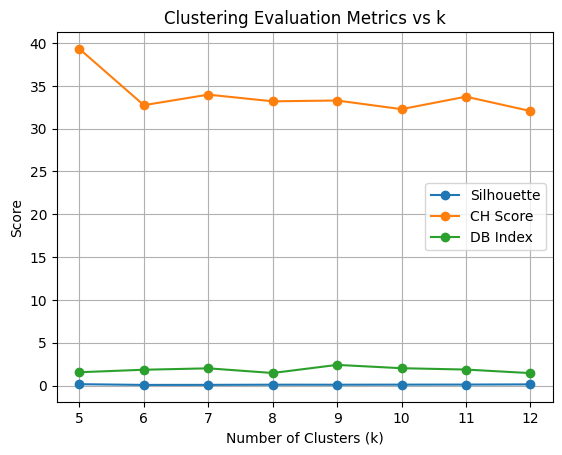

In [20]:
import matplotlib.pyplot as plt

plt.plot(metrics_df["k"], metrics_df["Silhouette"], marker='o', label="Silhouette")
plt.plot(metrics_df["k"], metrics_df["Calinski-Harabasz"], marker='o', label="CH Score")
plt.plot(metrics_df["k"], metrics_df["Davies-Bouldin"], marker='o', label="DB Index")

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Score")
plt.title("Clustering Evaluation Metrics vs k")
plt.legend()
plt.grid()

plt.savefig("figure1.png", dpi=300, bbox_inches="tight")
plt.show()

Cluster visualization

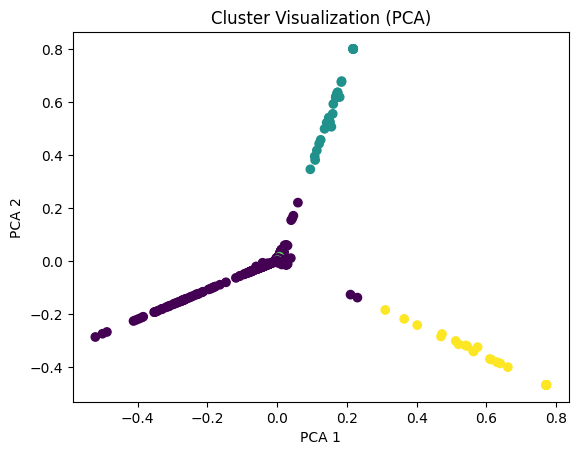

In [21]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_reduced)

plt.scatter(X_pca[:,0], X_pca[:,1], c=df["cluster"], cmap='viridis')
plt.title("Cluster Visualization (PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.savefig("figure2.png", dpi=300, bbox_inches="tight")
plt.show()

hashtag bar chart

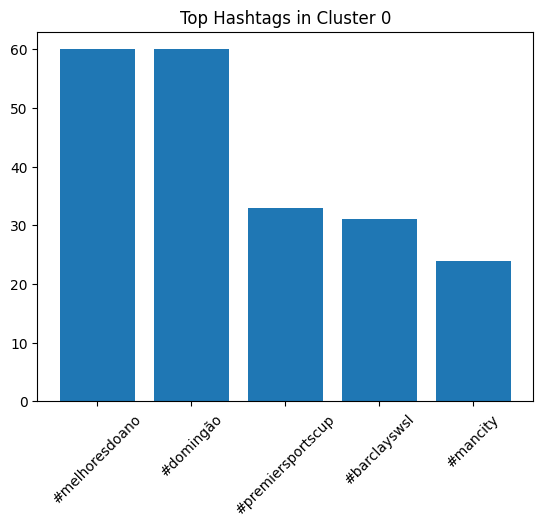

In [22]:
from collections import Counter

cluster_0_tags = []

for t in df[df["cluster"] == 0]["hashtags"]:
    cluster_0_tags.extend(t)

top_tags = Counter(cluster_0_tags).most_common(5)

tags, counts = zip(*top_tags)

plt.bar(tags, counts)
plt.title("Top Hashtags in Cluster 0")
plt.xticks(rotation=45)

plt.savefig("figure3.png", dpi=300, bbox_inches="tight")
plt.show()